# Klasifikacija zadovoljstva kupaca
U ovom notebooku se analizira problem predikcije zadovoljstva kupaca na osnovu podataka o porudzbinama, placanju, isporuci, proizvodima i prodavcima.

Ciljna promenljiva je `satisfaction_class`, koja predstavlja kategoriju zadovoljstva kupca na osnovu ocene recenzije:

- 0 - nezadovoljan kupac
- 1 - neutralan kupac
- 2 - zadovoljan kupac

Za resavanje problema koriste se dva algoritma klasifikacije:

- Random Forest
- XGBoost

Cilj je da se uporede performanse modela i utvrdi koliko se zadovoljstvo kupca moze predvideti na osnovu dostupnih atributa.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import joblib

import warnings
warnings.filterwarnings("ignore")


In [3]:
satisfaction_table = pd.read_csv("../data/processed/satisfaction_table.csv")

satisfaction_table.head()

,order_id,customer_unique_id,customer_state,order_status,items_count,total_items_value,total_freight_value,avg_item_price,unique_products,unique_sellers,...,preferred_payment_type,main_category,delivery_days,estimated_delivery_days,delay_days,is_delayed,order_month,order_year,review_score,satisfaction_class
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,delivered,1.0,29.99,8.72,29.99,1.0,1.0,...,voucher,housewares,8.0,15,-8.0,0,10,2017,4.0,2
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,delivered,1.0,118.70,22.76,118.70,1.0,1.0,...,boleto,perfumery,13.0,19,-6.0,0,7,2018,4.0,2
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,delivered,1.0,159.90,19.22,159.90,1.0,1.0,...,credit_card,auto,9.0,26,-18.0,0,8,2018,5.0,2
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,RN,delivered,1.0,45.00,27.20,45.00,1.0,1.0,...,credit_card,pet_shop,13.0,26,-13.0,0,11,2017,5.0,2
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,SP,delivered,1.0,19.90,8.72,19.90,1.0,1.0,...,credit_card,stationery,2.0,12,-10.0,0,2,2018,5.0,2


In [4]:
print("Broj redova:", satisfaction_table.shape[0])
print("Broj kolona:", satisfaction_table.shape[1])

Broj redova: 98673
Broj kolona: 24


Tabela `satisfaction_table` predstavlja pripremljenu tabelu za problem klasifikacije zadovoljstva kupaca. Svaki red odgovara jednoj porudzbini, dok atributi opisuju karakteristike porudzbine, isporuke, placanja, proizvoda i prodavca.

## Analiza ciljne promenljive

In [5]:
distribution_table = pd.DataFrame({
    "Klasa": ["0", "1", "2"],
    "Procenat (%)": (
        satisfaction_table["satisfaction_class"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
        .values
    )
})

distribution_table

,Klasa,Procenat (%)
0,0,14.64
1,1,8.25
2,2,77.11


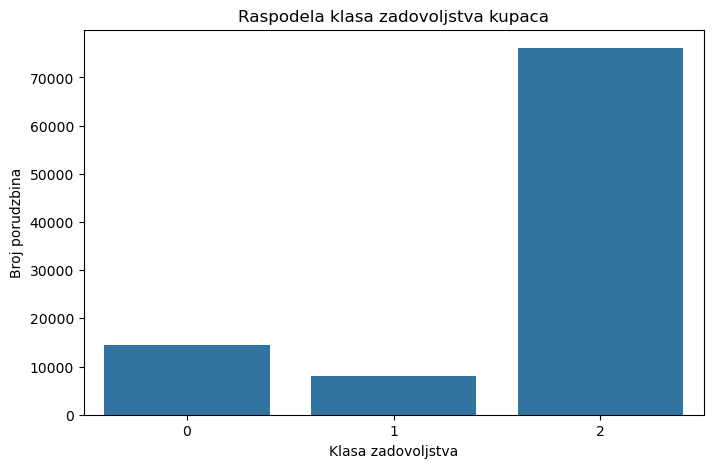

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=satisfaction_table,
    x="satisfaction_class"
)

plt.title("Raspodela klasa zadovoljstva kupaca")
plt.xlabel("Klasa zadovoljstva")
plt.ylabel("Broj porudzbina")

plt.show()

Na osnovu raspodele ciljne promenljive moze se uociti izrazena neuravnotezenost klasa. Najveci broj porudzbina pripada klasi zadovoljnih kupaca (klasa 2), dok su neutralni i nezadovoljni kupci znatno manje zastupljeni.

Ovakva raspodela je ocekivana za Olist skup podataka, s obzirom da vecina korisnika daje visoke ocene nakon uspesno realizovanih porudzbina.

Zbog neuravnotezenosti klasa, performanse modela nece biti ocenjene samo na osnovu metrike Accuracy, vec ce biti analizirane i metrike Precision, Recall i F1-score, koje daju realniju sliku kvaliteta klasifikacije.

## Analiza atributa

In [7]:
satisfaction_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98673 entries, 0 to 98672
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  98673 non-null  object 
 1   customer_unique_id        98673 non-null  object 
 2   customer_state            98673 non-null  object 
 3   order_status              98673 non-null  object 
 4   items_count               98673 non-null  float64
 5   total_items_value         98673 non-null  float64
 6   total_freight_value       98673 non-null  float64
 7   avg_item_price            98673 non-null  float64
 8   unique_products           98673 non-null  float64
 9   unique_sellers            98673 non-null  float64
 10  unique_categories         98673 non-null  float64
 11  total_payment_value       98673 non-null  float64
 12  avg_payment_installments  98673 non-null  float64
 13  max_payment_installments  98673 non-null  float64
 14  prefer

In [8]:
satisfaction_table.dtypes.value_counts()

float64    13
object      6
int64       5
Name: count, dtype: int64

Skup podataka sadrzi numericke i kategoricke atribute. Pre treniranja modela potrebno je ukloniti identifikatore i transformisati kategoricke atribute u numericki oblik kako bi ih algoritmi mogli koristiti.

Atribut review_score predstavlja originalnu ocenu koju je kupac ostavio nakon kupovine.

Pošto je cilj modela predikcija zadovoljstva kupaca, korišćenje ovog atributa dovelo bi do curenja informacija (data leakage), jer direktno sadrži informaciju iz koje je izvedena ciljna promenljiva.

Zbog toga je review_score uklonjen iz skupa atributa pre treniranja modela.

In [9]:
data = satisfaction_table.drop(
    columns=[
        "order_id",
        "customer_unique_id",
        "review_score"
    ]
)

In [10]:
categorical_columns = [
    "customer_state",
    "order_status",
    "preferred_payment_type",
    "main_category"
]

data_encoded = pd.get_dummies(
    data,
    columns=categorical_columns,
    drop_first=True
)

data_encoded.shape

(98673, 128)

Kategoricki atributi transformisani su primenom One-Hot Encoding tehnike. Na ovaj nacin svaka kategorija predstavlja se posebnom binarnom promenljivom, sto omogucava primenu algoritama masinskog ucenja.

## Podela na trening i test skup

In [11]:
X = data_encoded.drop(
    columns=["satisfaction_class"]
)

y = data_encoded["satisfaction_class"]

print(X.shape)
print(y.shape)

(98673, 127)
(98673,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
print("Trening skup:")
print(X_train.shape)

print("\nTest skup:")
print(X_test.shape)

Trening skup:
(78938, 127)

Test skup:
(19735, 127)


In [14]:
distribution = pd.DataFrame({
    "Trening (%)": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
    "Test (%)": (
        y_test.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

distribution


,Trening (%),Test (%)
satisfaction_class,,
0,14.64,14.64
1,8.25,8.24
2,77.11,77.11


Pošto najveći broj instanci pripada klasi zadovoljnih kupaca, modeli mogu ostvariti visoku tačnost čak i ukoliko slabije prepoznaju manjinske klase.

## Skaliranje numerickih atributa

Pre treniranja modela primenjuje se standardizacija numeričkih atributa. `StandardScaler` se fituje iskljucivo na trening skupu, a zatim se ista transformacija primenjuje na trening i test skup. Ovo je važno kako ne bi došlo do curenja informacija iz test skupa.

In [15]:
numeric_columns = data.drop(columns=["satisfaction_class"])
numeric_columns = numeric_columns.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

# Posle One-Hot Encoding-a nazivi originalnih numeričkih kolona ostaju isti,
# pa skaliramo samo te kolone, a binarne dummy kolone ostavljamo u obliku 0/1.
numeric_columns = [col for col in numeric_columns if col in X_train.columns]

print("Broj numeričkih atributa za skaliranje:", len(numeric_columns))
print(numeric_columns)

Broj numeričkih atributa za skaliranje: 16
['items_count', 'total_items_value', 'total_freight_value', 'avg_item_price', 'unique_products', 'unique_sellers', 'unique_categories', 'total_payment_value', 'avg_payment_installments', 'max_payment_installments', 'delivery_days', 'estimated_delivery_days', 'delay_days', 'is_delayed', 'order_month', 'order_year']


In [16]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

X_train_scaled.head()

,items_count,total_items_value,total_freight_value,avg_item_price,unique_products,unique_sellers,unique_categories,total_payment_value,avg_payment_installments,max_payment_installments,...,main_category_signaling_and_security,main_category_small_appliances,main_category_small_appliances_home_oven_and_coffee,main_category_sports_leisure,main_category_stationery,main_category_tablets_printing_image,main_category_telephony,main_category_toys,main_category_unknown,main_category_watches_gifts
77186,-0.261078,6.561456,1.061475,7.315686,-0.165462,-0.110448,-0.087029,6.299507,2.627589,2.606160,...,False,False,True,False,False,False,False,False,False,False
1455,-0.261078,-0.082656,-0.125745,-0.029863,-0.165462,-0.110448,-0.087029,-0.094284,-0.709092,-0.710886,...,False,False,False,False,False,False,False,False,False,False
12473,1.622222,-0.323060,0.042529,-0.482069,-0.165462,-0.110448,-0.087029,-0.304946,-0.709092,-0.710886,...,False,False,False,False,False,False,False,False,False,True
4546,-0.261078,-0.588083,-0.239633,-0.588649,-0.165462,-0.110448,-0.087029,-0.582977,-0.709092,-0.710886,...,False,False,False,False,False,False,False,False,False,False
91616,-0.261078,-0.202617,-0.061132,-0.162489,-0.165462,-0.110448,-0.087029,-0.201300,0.217763,1.131917,...,False,False,False,False,False,False,False,False,False,True


## Pomocne funkcije za evaluaciju

Da bi evaluacija bila jedinstvena za sve algoritme, koristi se ista funkcija za racunanje metrika i isti format prikaza rezultata. Za svaki model racunaju se Accuracy, Precision, Recall i F1-score, pri cemu se za viseklasni problem koristi `weighted` prosečavanje.

In [17]:
all_results = []


def evaluate_model(
    model_name,
    y_train_true,
    y_train_pred,
    y_test_true,
    y_test_pred
):
    train_accuracy = accuracy_score(
        y_train_true,
        y_train_pred
    )
    train_precision = precision_score(
        y_train_true,
        y_train_pred,
        average="weighted",
        zero_division=0
    )
    train_recall = recall_score(
        y_train_true,
        y_train_pred,
        average="weighted",
        zero_division=0
    )
    train_f1 = f1_score(
        y_train_true,
        y_train_pred,
        average="weighted",
        zero_division=0
    )

    test_accuracy = accuracy_score(
        y_test_true,
        y_test_pred
    )
    test_precision = precision_score(
        y_test_true,
        y_test_pred,
        average="weighted",
        zero_division=0
    )
    test_recall = recall_score(
        y_test_true,
        y_test_pred,
        average="weighted",
        zero_division=0
    )
    test_f1 = f1_score(
        y_test_true,
        y_test_pred,
        average="weighted",
        zero_division=0
    )

    results = pd.DataFrame({
        "Algoritam": [model_name],
        "Train Accuracy": [train_accuracy],
        "Test Accuracy": [test_accuracy],
        "Accuracy gap": [
            train_accuracy - test_accuracy
        ],
        "Train Precision": [train_precision],
        "Test Precision": [test_precision],
        "Train Recall": [train_recall],
        "Test Recall": [test_recall],
        "Train F1-score": [train_f1],
        "Test F1-score": [test_f1],
        "F1 gap": [
            train_f1 - test_f1
        ]
    })

    all_results.append(results)

    train_test_table = pd.DataFrame({
        "Skup": ["Trening", "Test"],
        "Accuracy": [
            train_accuracy,
            test_accuracy
        ],
        "Precision": [
            train_precision,
            test_precision
        ],
        "Recall": [
            train_recall,
            test_recall
        ],
        "F1-score": [
            train_f1,
            test_f1
        ]
    })

    print(f"Rezultati za algoritam: {model_name}")
    display(train_test_table.round(4))

    print(
        f"\nRazlika u Accuracy metrici: "
        f"{train_accuracy - test_accuracy:.4f}"
    )
    print(
        f"Razlika u F1-score metrici: "
        f"{train_f1 - test_f1:.4f}"
    )

    print("\nClassification report - trening skup:")
    print(
        classification_report(
            y_train_true,
            y_train_pred,
            zero_division=0
        )
    )

    print("\nClassification report - test skup:")
    print(
        classification_report(
            y_test_true,
            y_test_pred,
            zero_division=0
        )
    )

    return results


def plot_confusion_matrix(
    y_true,
    y_pred,
    title,
    cmap="Blues"
):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        linewidths=0.5
    )
    plt.title(title)
    plt.xlabel("Predviđena klasa")
    plt.ylabel("Stvarna klasa")
    plt.tight_layout()
    plt.show()

## Random Forest

Random Forest predstavlja ansambl metodu zasnovanu na velikom broju stabala odlucivanja. Svako stablo trenira se na slucajnom podskupu podataka i atributa, dok se konacna odluka donosi glasanjem svih stabala.

Prednost ovog algoritma ogleda se u dobroj otpornosti na sum u podacima, sposobnosti rada sa velikim brojem atributa i mogucnosti procene znacaja pojedinacnih atributa.

Parametar `class_weight="balanced"` automatski dodeljuje vece tezine manjinskim klasama, dok dominantna klasa dobija manju tezinu. Na ovaj nacin model se podstice da vise paznje posveti klasama koje imaju manji broj instanci.

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_train_predictions = rf_model.predict(
    X_train_scaled
)

rf_test_predictions = rf_model.predict(
    X_test_scaled
)

In [19]:
rf_results = evaluate_model(
    model_name="Random Forest",
    y_train_true=y_train,
    y_train_pred=rf_train_predictions,
    y_test_true=y_test,
    y_test_pred=rf_test_predictions
)

Rezultati za algoritam: Random Forest


,Skup,Accuracy,Precision,Recall,F1-score
0,Trening,0.7254,0.7563,0.7254,0.7393
1,Test,0.7142,0.7467,0.7142,0.7289



Razlika u Accuracy metrici: 0.0112
Razlika u F1-score metrici: 0.0104

Classification report - trening skup:
              precision    recall  f1-score   support

           0       0.52      0.57      0.54     11559
           1       0.17      0.24      0.20      6509
           2       0.86      0.81      0.83     60870

    accuracy                           0.73     78938
   macro avg       0.52      0.54      0.53     78938
weighted avg       0.76      0.73      0.74     78938


Classification report - test skup:
              precision    recall  f1-score   support

           0       0.50      0.57      0.53      2890
           1       0.13      0.18      0.15      1627
           2       0.86      0.80      0.83     15218

    accuracy                           0.71     19735
   macro avg       0.49      0.51      0.50     19735
weighted avg       0.75      0.71      0.73     19735



### Analiza generalizacije

Random Forest model ostvaruje veoma slicne rezultate na trening i test skupu. Vrednost weighted F1-score na trening skupu iznosi 0.7393, dok je na test skupu ostvarena vrednost 0.7289. Razlika izmedju ove dve vrednosti iznosi svega 0.0104, sto ukazuje da model dobro generalizuje i ne pokazuje znacajne znake overfitting-a.

Analiza rezultata po klasama pokazuje da model uspesno klasifikuje dominantnu klasu, dok je tacnost klasifikacije manjinske klase i dalje ogranicena usled izrazene neravnoteze u podacima.

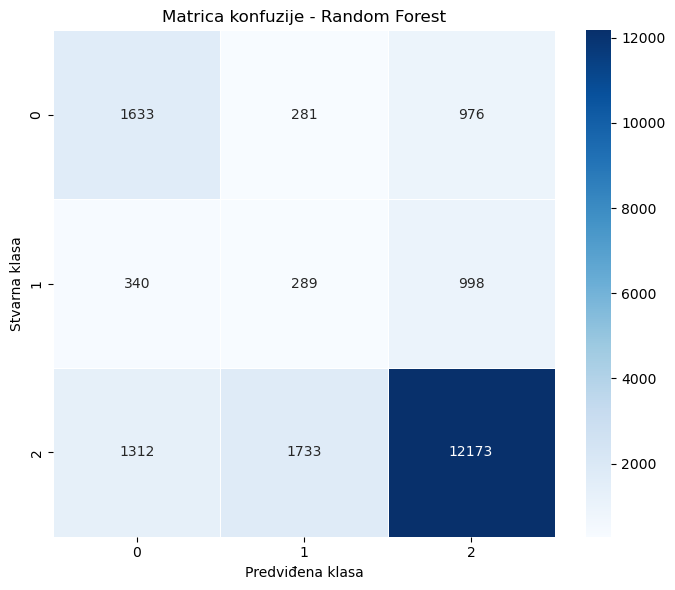

In [20]:
plot_confusion_matrix(
    y_test,
    rf_test_predictions,
    "Matrica konfuzije - Random Forest",
    cmap="Blues"
)

### Analiza rezultata Random Forest modela

Random Forest model ostvario je tacnost od 71.42%, sto predstavlja dobar rezultat za problem klasifikacije zadovoljstva kupaca. Posmatrajuci matricu konfuzije i klasifikacioni izvestaj, moze se primetiti da model veoma uspesno prepoznaje klasu 2, koja je ujedno i najzastupljenija u skupu podataka. Sa druge strane, performanse na klasama 0 i posebno 1 su znatno slabije, sto ukazuje da model ima poteskoce pri razlikovanju manje zastupljenih kategorija zadovoljstva.

Dobijeni rezultati potvrdjuju da neuravnotezenost klasa utice na ponasanje modela, zbog cega sama tacnost nije dovoljan pokazatelj kvaliteta. Ipak, Random Forest uspeva da prepozna znacajan deo obrazaca u podacima i predstavlja dobru osnovu za poredjenje sa ostalim algoritmima koriscenim u ovom istrazivanju.

### Analiza znacaja atributa

In [21]:
feature_importance = pd.DataFrame({
    "atribut": X.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
)

feature_importance.head(15)


,atribut,importance
12,delay_days,0.185130
44,order_status_delivered,0.146364
13,is_delayed,0.146012
10,delivery_days,0.133020
0,items_count,0.038398
47,order_status_shipped,0.028422
2,total_freight_value,0.026769
48,order_status_unavailable,0.023408
11,estimated_delivery_days,0.021391
3,avg_item_price,0.020973


Analiza znacaja atributa pokazuje da su najvazniji faktori za predikciju zadovoljstva kupaca povezani sa procesom isporuke.

Najveci znacaj imaju atributi:

- delay_days
- delivery_days
- order_status_delivered
- is_delayed

Ovi rezultati ukazuju da kasnjenje i ukupno trajanje isporuke imaju najveci uticaj na ocene koje kupci ostavljaju nakon realizacije porudzbine.

Pored logistickih faktora, znacajan uticaj imaju i finansijski atributi kao sto su vrednost porudzbine, cena dostave i prosecna cena proizvoda. Sa druge strane, atributi povezani sa nacinom placanja i brojem rata imaju znatno manji doprinos modelu.

Dobijeni rezultati potvrdjuju da je kvalitet logisticke usluge jedan od kljucnih faktora zadovoljstva kupaca u elektronskoj trgovini.

## XGBoost

XGBoost (Extreme Gradient Boosting) predstavlja jednu od najuspesnijih metoda ansambl ucenja. Za razliku od Random Forest algoritma koji gradi stabla nezavisno jedno od drugog, XGBoost gradi stabla sekvencijalno, pri cemu svako novo stablo pokusava da ispravi greske prethodnih.

Zbog toga XGBoost cesto ostvaruje bolje performanse od klasicnih algoritama zasnovanih na stablima odlucivanja, posebno na strukturisanim tabelarnim podacima.

In [22]:
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train_scaled,
    y_train
)


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [23]:
xgb_train_predictions = xgb_model.predict(
    X_train_scaled
)

xgb_test_predictions = xgb_model.predict(
    X_test_scaled
)


In [24]:
xgb_results = evaluate_model(
    model_name="XGBoost",
    y_train_true=y_train,
    y_train_pred=xgb_train_predictions,
    y_test_true=y_test,
    y_test_pred=xgb_test_predictions
)

Rezultati za algoritam: XGBoost


,Skup,Accuracy,Precision,Recall,F1-score
0,Trening,0.8318,0.8426,0.8318,0.7876
1,Test,0.8172,0.7422,0.8172,0.7699



Razlika u Accuracy metrici: 0.0146
Razlika u F1-score metrici: 0.0177

Classification report - trening skup:
              precision    recall  f1-score   support

           0       0.79      0.48      0.60     11559
           1       1.00      0.02      0.03      6509
           2       0.84      0.99      0.90     60870

    accuracy                           0.83     78938
   macro avg       0.88      0.49      0.51     78938
weighted avg       0.84      0.83      0.79     78938


Classification report - test skup:
              precision    recall  f1-score   support

           0       0.71      0.43      0.54      2890
           1       0.00      0.00      0.00      1627
           2       0.83      0.98      0.90     15218

    accuracy                           0.82     19735
   macro avg       0.51      0.47      0.48     19735
weighted avg       0.74      0.82      0.77     19735



### Analiza generalizacije

Performanse XGBoost modela analizirane su na trening i test skupu kako bi se procenila sposobnost generalizacije modela. Na trening skupu ostvarena je vrednost weighted F1-score od 0.7876, dok je na test skupu ostvarena vrednost 0.7699. Razlika izmedju ove dve vrednosti iznosi svega 0.0177, sto ukazuje da model ne pokazuje znacajne znake overfitting-a i uspesno generalizuje na nevidjene podatke.

Iako model ostvaruje dobre ukupne rezultate, analiza po klasama pokazuje da gotovo u potpunosti zanemaruje najmanje zastupljenu klasu. Zbog toga je u nastavku ispitana primena tehnike SMOTEENN, sa ciljem poboljsanja klasifikacije manjinske klase bez znacajnog narusavanja ukupnih performansi modela.

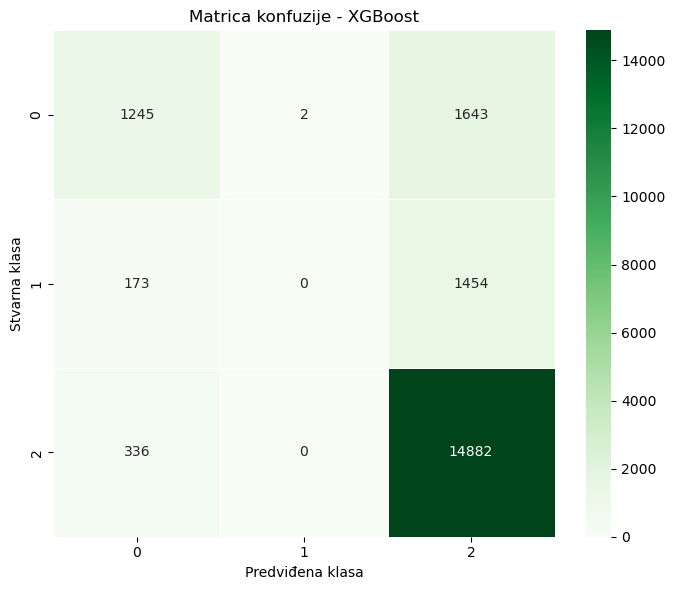

In [25]:
plot_confusion_matrix(
    y_test,
    xgb_test_predictions,
    "Matrica konfuzije - XGBoost",
    cmap="Greens"
)

### Analiza rezultata XGBoost modela

XGBoost model ostvario je najbolju ukupnu tačnost i najviše vrednosti većine evaluacionih metrika.

Međutim, zbog izražene neuravnoteženosti klasa model i dalje pokazuje slabije rezultate na najmanje zastupljenim klasama. Zbog toga visoka tačnost ne znači nužno podjednako uspešno prepoznavanje svih nivoa zadovoljstva kupaca.

I pored toga, XGBoost predstavlja najuspešniji model u okviru sprovedenih eksperimenata.

## XGBoost sa SMOTEENN balansiranjem

Rezultati osnovnog XGBoost modela pokazali su izrazenu dominaciju vecinske klase i veoma slabu sposobnost prepoznavanja neutralnih kupaca.

Zbog toga se primenjuje SMOTEENN tehnika koja kombinuje sinteticko generisanje novih instanci manjinskih klasa i uklanjanje potencijalno problematicnih primera iz trening skupa.

In [26]:
from imblearn.combine import SMOTEENN

In [27]:
smoteenn = SMOTEENN(
    random_state=42
)

X_train_se, y_train_se = smoteenn.fit_resample(
    X_train_scaled,
    y_train
)

print("Pre SMOTEENN:")
print(y_train.value_counts())

print("\nPosle SMOTEENN:")
print(y_train_se.value_counts())


Pre SMOTEENN:
satisfaction_class
2    60870
0    11559
1     6509
Name: count, dtype: int64

Posle SMOTEENN:
satisfaction_class
1    57246
0    55176
2    24956
Name: count, dtype: int64


In [28]:
xgb_se = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1
)

xgb_se.fit(
    X_train_se,
    y_train_se
)

xgb_se_train_predictions = xgb_se.predict(
    X_train_scaled
)

xgb_se_test_predictions = xgb_se.predict(
    X_test_scaled
)

In [29]:
xgb_se_results = evaluate_model(
    model_name="XGBoost + SMOTEENN",
    y_train_true=y_train,
    y_train_pred=xgb_se_train_predictions,
    y_test_true=y_test,
    y_test_pred=xgb_se_test_predictions
)

Rezultati za algoritam: XGBoost + SMOTEENN


,Skup,Accuracy,Precision,Recall,F1-score
0,Trening,0.7220,0.7624,0.7220,0.7389
1,Test,0.6977,0.7439,0.6977,0.7175



Razlika u Accuracy metrici: 0.0242
Razlika u F1-score metrici: 0.0213

Classification report - trening skup:
              precision    recall  f1-score   support

           0       0.50      0.62      0.55     11559
           1       0.20      0.30      0.24      6509
           2       0.87      0.79      0.83     60870

    accuracy                           0.72     78938
   macro avg       0.52      0.57      0.54     78938
weighted avg       0.76      0.72      0.74     78938


Classification report - test skup:
              precision    recall  f1-score   support

           0       0.47      0.58      0.52      2890
           1       0.13      0.19      0.15      1627
           2       0.86      0.77      0.82     15218

    accuracy                           0.70     19735
   macro avg       0.49      0.52      0.50     19735
weighted avg       0.74      0.70      0.72     19735



### Analiza generalizacije

Model XGBoost sa primenom tehnike SMOTEENN ostvaruje weighted F1-score od 0.7389 na trening skupu i 0.7175 na test skupu. Razlika izmedju trening i test rezultata iznosi 0.0213, sto ukazuje da model zadrzava dobru sposobnost generalizacije i ne pokazuje znacajne znake overfitting-a.

U odnosu na osnovni XGBoost model, primena tehnike SMOTEENN dovodi do blagog pada ukupnih performansi. Medjutim, analiza po klasama pokazuje da model uspesnije prepoznaje manjinsku klasu, koja u osnovnom modelu gotovo uopste nije bila klasifikovana. Time je postignuta bolja ravnoteza izmedju ukupne tacnosti i sposobnosti klasifikacije svih klasa.

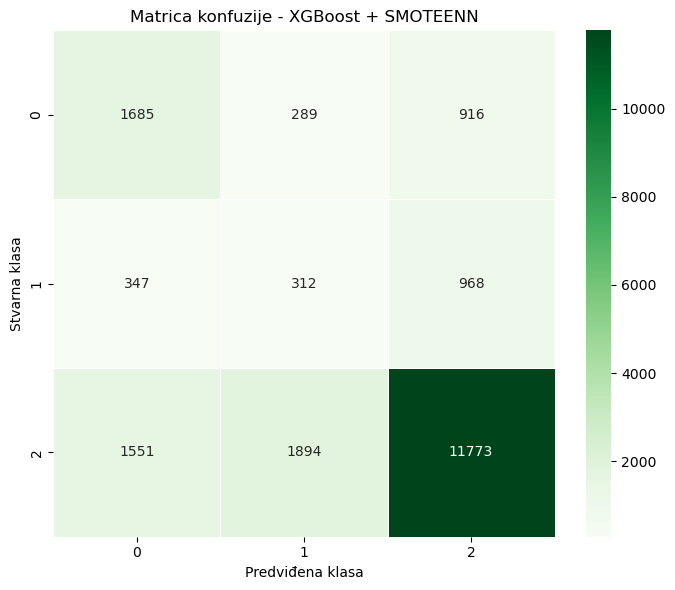

In [30]:
plot_confusion_matrix(
    y_test,
    xgb_se_test_predictions,
    "Matrica konfuzije - XGBoost + SMOTEENN",
    cmap="Greens"
)

### Analiza rezultata XGBoost + SMOTEENN modela

Primenom SMOTEENN tehnike postignut je drugaciji balans izmedju ukupne tacnosti modela i sposobnosti prepoznavanja manjinskih klasa. Iako su Accuracy i F1-score nizi u odnosu na osnovni XGBoost model, rezultati pokazuju da model uspesnije prepoznaje manje zastupljene kategorije zadovoljstva kupaca.

Najveca razlika uocava se kod klase 1, koju osnovni XGBoost model prakticno nije prepoznavao, dok XGBoost + SMOTEENN uspeva da klasifikuje deo tih primera. To ukazuje da je balansiranje podataka doprinelo ravnomernijem tretmanu svih klasa i smanjenju uticaja dominantne klase tokom treniranja.

Zbog toga se moze zakljuciti da XGBoost + SMOTEENN predstavlja zanimljivu alternativu osnovnom XGBoost modelu. Ukoliko je prioritet sto bolje prepoznavanje nezadovoljnih i neutralnih kupaca, ovakav pristup moze biti korisniji uprkos nesto nizoj ukupnoj tacnosti.


In [31]:
comparison_results = (
    pd.concat(
        all_results,
        ignore_index=True
    )
    .sort_values(
        "Test F1-score",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison_results.round(4)

,Algoritam,Train Accuracy,Test Accuracy,Accuracy gap,Train Precision,Test Precision,Train Recall,Test Recall,Train F1-score,Test F1-score,F1 gap
0,XGBoost,0.8318,0.8172,0.0146,0.8426,0.7422,0.8318,0.8172,0.7876,0.7699,0.0177
1,Random Forest,0.7254,0.7142,0.0112,0.7563,0.7467,0.7254,0.7142,0.7393,0.7289,0.0104
2,XGBoost + SMOTEENN,0.7220,0.6977,0.0242,0.7624,0.7439,0.7220,0.6977,0.7389,0.7175,0.0213


## Poredjenje modela i zakljucak

Na osnovu sprovedenih eksperimenata, XGBoost je ostvario najbolje ukupne rezultate sa tacnoscu od 81.72% i najvisim F1-score pokazateljem. Random Forest je ostvario nesto slabije performanse, dok je XGBoost + SMOTEENN imao najnizu ukupnu tacnost.

Ipak, analiza matrica konfuzije pokazuje da sama Accuracy metrika nije dovoljna za procenu kvaliteta modela. Osnovni XGBoost model veoma dobro prepoznaje dominantnu klasu, ali gotovo u potpunosti zanemaruje klasu 1. Sa druge strane, primena SMOTEENN tehnike poboljsava prepoznavanje manjinskih klasa, posebno klase 1, ali uz odredjeni pad ukupnih performansi. Random Forest predstavlja kompromis izmedju ova dva pristupa i pokazuje stabilnije ponasanje na svim klasama.

Moze se zakljuciti da je XGBoost najbolji izbor ukoliko je cilj postizanje sto vece ukupne tacnosti. Medjutim, ukoliko je vazno prepoznati i manje zastupljene kategorije kupaca, posebno nezadovoljne i neutralne korisnike, modeli sa balansiranjem podataka mogu predstavljati korisnu alternativu. Zbog toga izbor modela treba prilagoditi konkretnim poslovnim potrebama, a ne zasnivati ga iskljucivo na Accuracy metrici.